# 01 — Pump detection v0 + event study

**Goal:** simplest possible pump detector, then look at the *average price path*
around detected events to see if there's a tradeable shape (run-up to fade).

Detector v0: cumulative 15-min return spike **and** volume surge over rolling median.
Train-only exploration.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

SYMBOL = '1000PEPEUSDT'
START, END = '2024-06-01', '2024-12-01'
print('coverage:', coverage(SYMBOL))
df = ohlcv(SYMBOL, START, END, tf='1min')
print('bars:', df.shape, '| from', df.index[0], 'to', df.index[-1])
df.head()

coverage: ('2024-01', '2025-09', 21)
bars: (263520, 5) | from 2024-06-01 00:00:00+00:00 to 2024-11-30 23:59:00+00:00


,open,high,low,close,volume
timestamp,,,,,
2024-06-01 00:00:00+00:00,0.015436,0.015462,0.015430,0.015443,17985100.0
2024-06-01 00:01:00+00:00,0.015443,0.015459,0.015404,0.015407,16672700.0
2024-06-01 00:02:00+00:00,0.015407,0.015419,0.015398,0.015402,18436000.0
2024-06-01 00:03:00+00:00,0.015402,0.015404,0.015354,0.015374,107100300.0
2024-06-01 00:04:00+00:00,0.015374,0.015404,0.015369,0.015390,19577100.0


## Detector signals

In [2]:
W = 15                          # detection window, minutes
ret = df['close'].pct_change(W)            # cumulative W-min return
vol_med = df['volume'].rolling(240, min_periods=60).median()
vol_surge = df['volume'].rolling(W).sum() / (vol_med * W)   # vol vs typical

sig = pd.DataFrame({'ret': ret, 'vol_surge': vol_surge, 'close': df['close']})
print('ret 15m quantiles:')
print(ret.quantile([0.5, 0.9, 0.99, 0.999, 0.9999]).round(4))
print('\nvol_surge quantiles:')
print(vol_surge.quantile([0.5, 0.9, 0.99, 0.999]).round(2))

ret 15m quantiles:
0.5000   -0.0000
0.9000    0.0073
0.9900    0.0216
0.9990    0.0446
0.9999    0.1028
Name: close, dtype: float64

vol_surge quantiles:
0.500     1.28
0.900     3.10
0.990     7.60
0.999    16.19
Name: volume, dtype: float64


In [3]:
# thresholds (intentionally coarse for v0)
RET_TH = 0.05      # +5% over 15 min
VOL_TH = 3.0       # 3x typical volume

raw = sig[(sig['ret'] > RET_TH) & (sig['vol_surge'] > VOL_TH)]
print(f'raw triggers: {len(raw)}')

# dedupe: collapse triggers within COOL minutes, keep the strongest (max ret)
COOL = 60
events = []
last_t = None
for t, row in raw.sort_index().iterrows():
    if last_t is None or (t - last_t).total_seconds() / 60 >= COOL:
        events.append(t)
        last_t = t
    else:
        # within cooldown: keep the larger-return one as the anchor
        if row['ret'] > sig.loc[events[-1], 'ret']:
            events[-1] = t
        last_t = t
events = pd.DatetimeIndex(events)
print(f'deduped events: {len(events)}  (~{len(events)/((df.index[-1]-df.index[0]).days):.2f}/day)')

raw triggers: 107
deduped events: 18  (~0.10/day)


## Event study — average path around the event

Align all events at t=0 (the trigger bar). Plot mean/median cumulative return
from -60 to +60 min. This tells us whether there's continuation (enter long)
and/or a fade (enter short).

usable events:

 18


[saved] notebooks\_out\01_event_study.png


WindowsPath('C:/projects/researchlab/notebooks/_out/01_event_study.png')

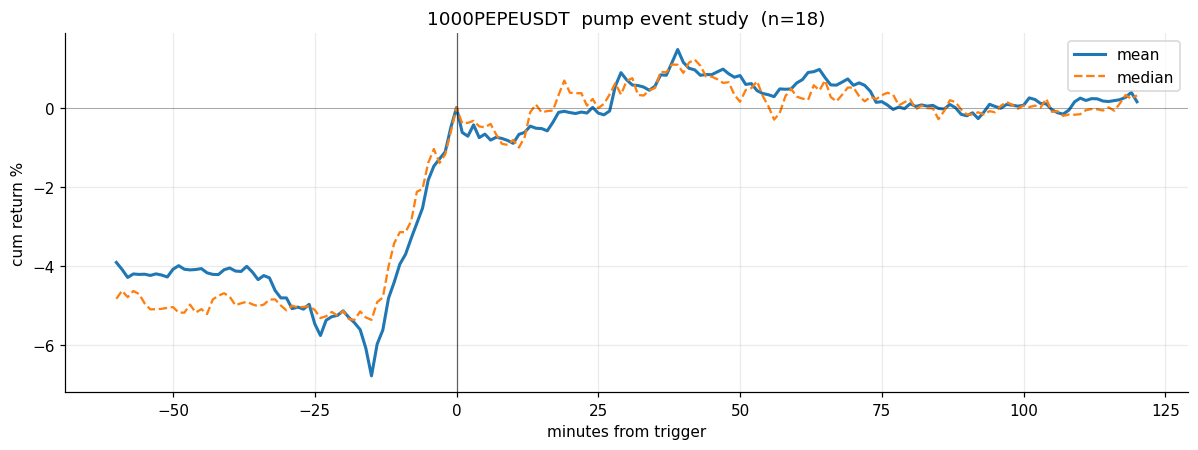

In [4]:
PRE, POST = 60, 120
close = df['close']
idx_pos = {t: i for i, t in enumerate(close.index)}

paths = []
for t in events:
    i = idx_pos.get(t)
    if i is None or i - PRE < 0 or i + POST >= len(close):
        continue
    seg = close.iloc[i - PRE: i + POST + 1].values
    paths.append(seg / seg[PRE] - 1.0)        # normalize to t=0
paths = np.array(paths)
print('usable events:', paths.shape[0])

offs = np.arange(-PRE, POST + 1)
mean_p = paths.mean(axis=0) * 100
med_p = np.median(paths, axis=0) * 100

fig, ax = plt.subplots()
ax.plot(offs, mean_p, label='mean', lw=2)
ax.plot(offs, med_p, label='median', lw=1.5, ls='--')
ax.axvline(0, color='k', lw=0.8, alpha=0.6)
ax.axhline(0, color='k', lw=0.6, alpha=0.3)
ax.set_xlabel('minutes from trigger'); ax.set_ylabel('cum return %')
ax.set_title(f'{SYMBOL}  pump event study  (n={paths.shape[0]})')
ax.legend()
show('01_event_study')

In [5]:
# forward return from t=0 at a few horizons (the long side)
for h in [5, 15, 30, 60, 120]:
    fwd = paths[:, PRE + h] - paths[:, PRE]
    print(f't+{h:>3}m:  mean {fwd.mean()*100:+.2f}%   median {np.median(fwd)*100:+.2f}%   '
          f'win% {(fwd>0).mean()*100:.0f}')

t+  5m:  mean -0.67%   median -0.50%   win% 39
t+ 15m:  mean -0.53%   median -0.12%   win% 50
t+ 30m:  mean +0.70%   median +0.67%   win% 67
t+ 60m:  mean +0.62%   median +0.28%   win% 56
t+120m:  mean +0.15%   median +0.31%   win% 50


## A few concrete examples

[saved] notebooks\_out\01_examples.png


WindowsPath('C:/projects/researchlab/notebooks/_out/01_examples.png')

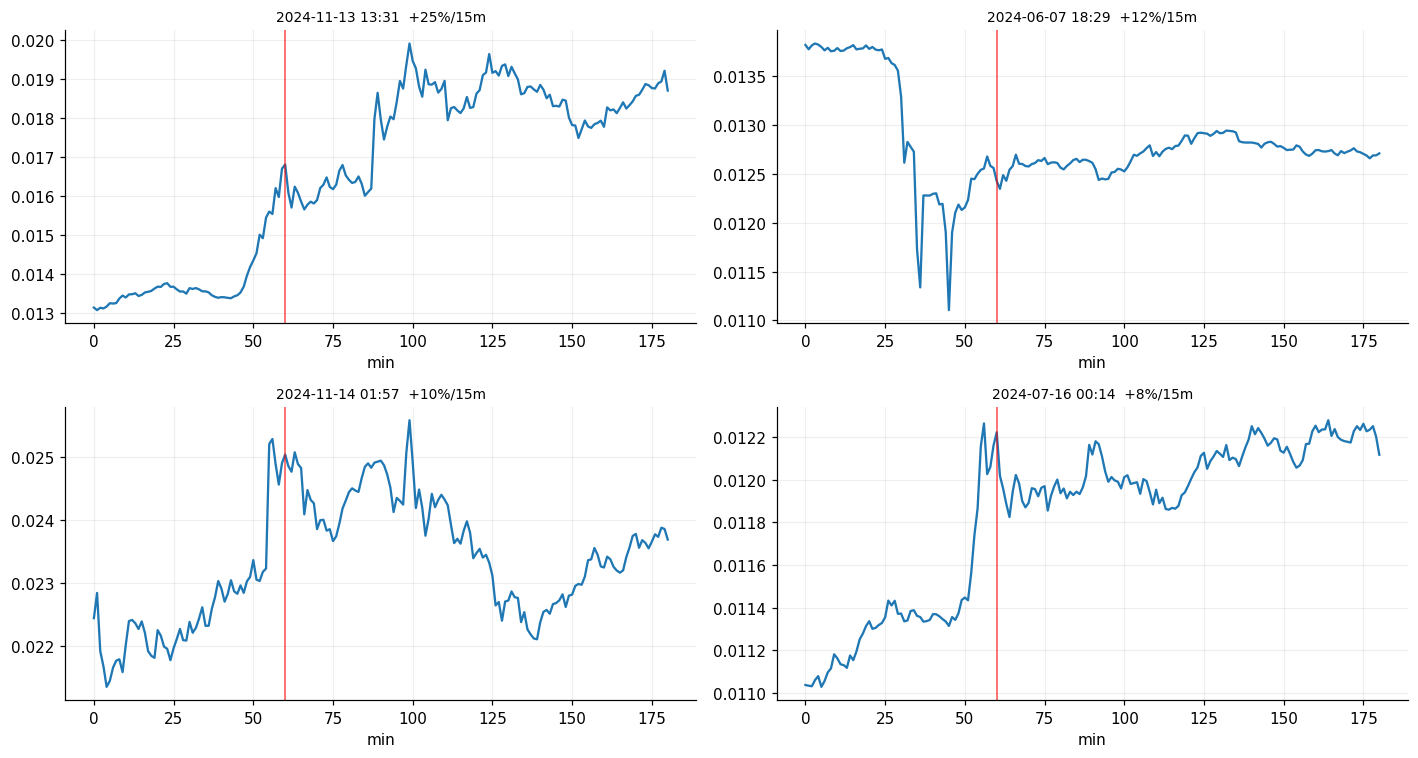

In [6]:
# strongest 4 events by trigger return
top = sig.loc[events].sort_values('ret', ascending=False).head(4).index
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, t in zip(axes.ravel(), top):
    i = idx_pos[t]
    win = close.iloc[max(0, i-PRE): i+POST+1]
    ax.plot(range(len(win)), win.values)
    ax.axvline(PRE, color='r', lw=1, alpha=0.7)
    ax.set_title(f"{t:%Y-%m-%d %H:%M}  +{sig.loc[t,'ret']*100:.0f}%/15m", fontsize=9)
    ax.set_xlabel('min'); ax.grid(alpha=0.2)
show('01_examples')